<a href="https://colab.research.google.com/github/amanilayouni/arene-des-algos--Amani_LAYOUNI-/blob/main/telco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/amanilayouni/arene-des-algos--Amani_LAYOUNI-.git


Cloning into 'arene-des-algos--Amani_LAYOUNI-'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 44 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 60.18 KiB | 2.15 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [9]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [10]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(" Forme du dataset :", df.shape)

print("\n Types des colonnes :")
print(df.dtypes)

print("\n Aperçu des premières lignes :")
print(df.head())

print("\n Vérification valeurs manquantes :")
print(df.isna().sum().sort_values(ascending=False).head(10))



 Forme du dataset : (7043, 21)

 Types des colonnes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

 Aperçu des premières lignes :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2         

In [11]:
import pandas as pd

def audit_qualite(df):
    print("Forme :", df.shape)

    print("\nTypes des colonnes :")
    print(df.dtypes)

    missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_percent = missing_percent[missing_percent > 0]

    print("\nTaux de valeurs manquantes (%) par colonne :")
    if len(missing_percent) == 0:
        print("Aucune valeur manquante détectée")
    else:
        print(missing_percent.round(2))

    if "Churn" not in df.columns:
        print("\nColonne Churn absente")
        return

    churn_counts = df["Churn"].value_counts(dropna=False)
    total = len(df)

    print("\nRépartition de la cible Churn :")
    for label in churn_counts.index:
        count = churn_counts[label]
        percent = (count / total) * 100 if total > 0 else 0
        print(label, count, round(percent, 1))

In [12]:
audit_qualite(df)

Forme : (7043, 21)

Types des colonnes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Taux de valeurs manquantes (%) par colonne :
Aucune valeur manquante détectée

Répartition de la cible Churn :
No 5174 73.5
Yes 1869 26.5


In [13]:
import numpy as np
import pandas as pd

def reparer_total_charges(df):
    df = df.copy()

    if "TotalCharges" not in df.columns:
        return df

    non_numeric_ratio = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().mean()

    if non_numeric_ratio == 1:
        raise ValueError("TotalCharges est 100% non numérique")

    before_nan = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

    df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    after_nan = df["TotalCharges"].isna().sum()
    new_nans = after_nan - (before_nan - df["TotalCharges"].isna().sum())

    median_value = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(median_value)

    return df

In [14]:
df2 = reparer_total_charges(df)

print(df2["TotalCharges"].dtype)
print(df2["TotalCharges"].isna().sum())
print(df2.shape)
print(df2.head())

float64
0
(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies

In [15]:
import pandas as pd

def encoder_features(df):
    df = df.copy()

    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])

    bool_map = {"Yes": 1, "No": 0}

    for col in df.columns:
        if df[col].dtype == "object":
            unique_vals = df[col].dropna().unique()

            if set(unique_vals).issubset({"Yes", "No"}):
                df[col] = df[col].map(bool_map)
            else:
                df = pd.get_dummies(df, columns=[col], drop_first=False)

    return df

In [16]:
df_enc = encoder_features(df)

print("Shape :", df_enc.shape)

Shape : (7043, 6572)


In [17]:
print(df_enc.select_dtypes(include="object").columns)

Index([], dtype='object')


In [18]:
print("customerID présent :", "customerID" in df_enc.columns)

customerID présent : False


In [19]:
binary_cols = [col for col in df_enc.columns if set(df_enc[col].dropna().unique()).issubset({0, 1})]

print("Colonnes binaires :", binary_cols[:10])

Colonnes binaires : ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender_Female', 'gender_Male', 'MultipleLines_No', 'MultipleLines_No phone service']


In [20]:
print("Colonnes avant :", df.shape[1])
print("Colonnes après :", df_enc.shape[1])

Colonnes avant : 21
Colonnes après : 6572


In [21]:
print(df_enc.dtypes.value_counts())

bool       6564
int64         7
float64       1
Name: count, dtype: int64


In [22]:
print(df_enc.head())

   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  Churn  gender_Female  gender_Male  ...  \
0           29.85      0           True        False  ...   
1           56.95      0          False         True  ...   
2           53.85      1          False         True  ...   
3           42.30      0          False         True  ...   
4           70.70      1           True        False  ...   

   TotalCharges_995.35  TotalCharges_996.45  TotalCharges_996.85  \
0                False                False                False   
1         

In [23]:
import numpy as np

def detecter_outliers_iqr(df, colonne):
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)
    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    outliers = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]

    return borne_basse, borne_haute, len(outliers)

=== DETECTION OUTLIERS IQR ===
tenure
borne basse: -60.0
borne haute: 124.0
outliers: 0
-----
MonthlyCharges
borne basse: -46.02499999999999
borne haute: 171.375
outliers: 0
-----
TotalCharges
borne basse: -4688.481250000001
borne haute: 8884.66875
outliers: 0
-----
=== BOXPLOTS ===


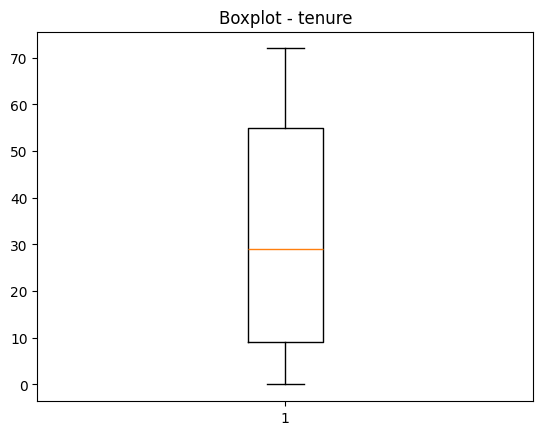

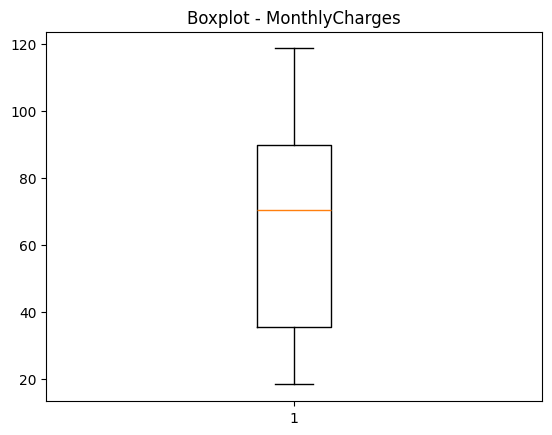

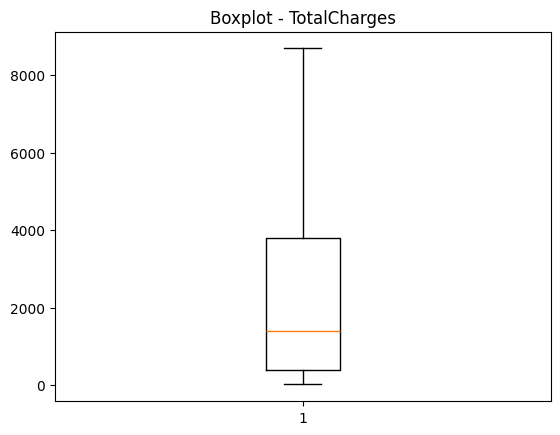

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):
    s = pd.to_numeric(df[colonne], errors="coerce")

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    outliers = s[(s < borne_basse) | (s > borne_haute)].count()

    return borne_basse, borne_haute, int(outliers)


def boxplots_iqr(df, colonnes):
    for c in colonnes:
        s = pd.to_numeric(df[c], errors="coerce")

        plt.figure()
        plt.boxplot(s.dropna())
        plt.title(f"Boxplot - {c}")
        plt.show()


def test_iqr(df):
    cols = ["tenure", "MonthlyCharges", "TotalCharges"]

    print("=== DETECTION OUTLIERS IQR ===")

    for c in cols:
        bmin, bmax, n = detecter_outliers_iqr(df, c)
        print(c)
        print("borne basse:", bmin)
        print("borne haute:", bmax)
        print("outliers:", n)
        print("-----")

    print("=== BOXPLOTS ===")
    boxplots_iqr(df, cols)


test_iqr(df)

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


def rapport_multicolinearite(df, colonnes_num):
    df_num = df[colonnes_num].copy()

    for c in df_num.columns:
        df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

    df_num = df_num.dropna()

    corr = df_num.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Heatmap corrélations")
    plt.show()

    vif_data = pd.DataFrame()
    vif_data["feature"] = df_num.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_num.values, i)
        for i in range(df_num.shape[1])
    ]

    print("=== VIF ===")
    print(vif_data)

    print("\n=== FEATURES PROBLEMATIQUES (VIF > 5) ===")
    print(vif_data[vif_data["VIF"] > 5])

    return vif_data

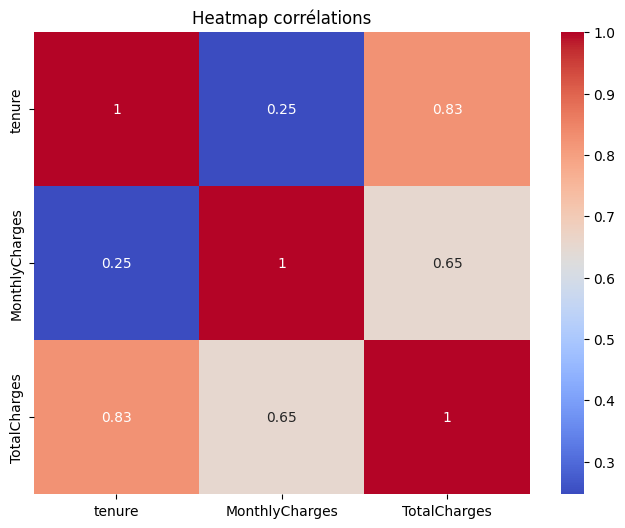

=== VIF ===
          feature       VIF
0          tenure  6.332432
1  MonthlyCharges  3.361075
2    TotalCharges  8.079181

=== FEATURES PROBLEMATIQUES (VIF > 5) ===
        feature       VIF
0        tenure  6.332432
2  TotalCharges  8.079181


In [26]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

vif = rapport_multicolinearite(df, colonnes_num)

In [27]:
df_test = df.copy()
df_test["tenure_copy"] = df_test["tenure"]

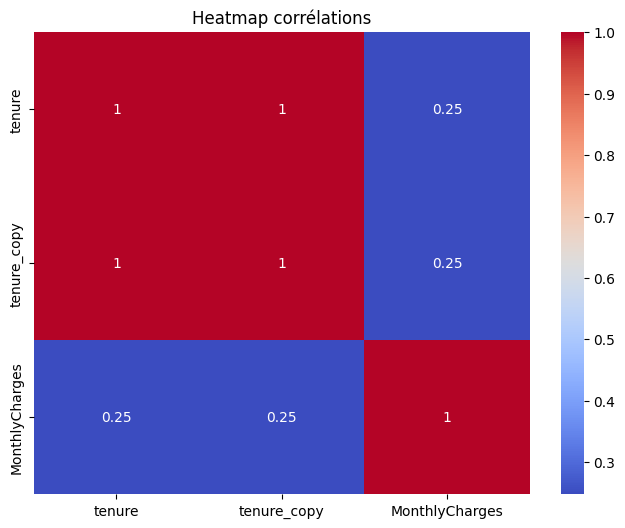

=== VIF ===
          feature       VIF
0          tenure       inf
1     tenure_copy       inf
2  MonthlyCharges  2.612607

=== FEATURES PROBLEMATIQUES (VIF > 5) ===
       feature  VIF
0       tenure  inf
1  tenure_copy  inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,tenure,inf
1,tenure_copy,inf
2,MonthlyCharges,2.612607


In [28]:
rapport_multicolinearite(df_test, ["tenure", "tenure_copy", "MonthlyCharges"])

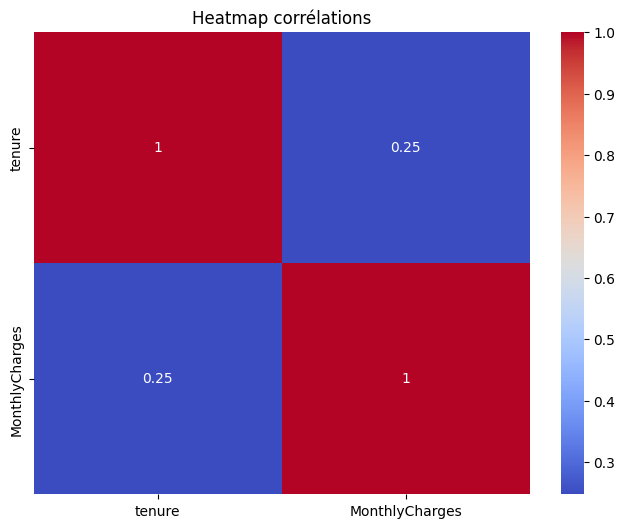

=== VIF ===
          feature       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607

=== FEATURES PROBLEMATIQUES (VIF > 5) ===
Empty DataFrame
Columns: [feature, VIF]
Index: []


,feature,VIF
0,tenure,2.612607
1,MonthlyCharges,2.612607


In [29]:
df_reduit = df.copy().drop(columns=["TotalCharges"])
rapport_multicolinearite(df_reduit, ["tenure", "MonthlyCharges"])

In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


def features_discriminantes(df, cible="Churn"):
    data = df.copy()

    if data[cible].dtype == "object":
        le = LabelEncoder()
        data[cible] = le.fit_transform(data[cible])

    X = data.drop(columns=[cible])
    y = data[cible]

    for c in X.columns:
        if X[c].dtype == "object":
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))

    corr = X.corrwith(y).abs().sort_values(ascending=False)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)

    importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    top_corr = corr.head(10)
    top_rf = importance.head(10)

    print("=== TOP 10 CORRELATION ===")
    print(top_corr)

    print("\n=== TOP 10 RANDOM FOREST IMPORTANCE ===")
    print(top_rf)

    return top_corr, top_rf

In [31]:
top_corr, top_rf = features_discriminantes(df)

=== TOP 10 CORRELATION ===
Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
OnlineBackup        0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection    0.178134
Dependents          0.164221
SeniorCitizen       0.150889
dtype: float64

=== TOP 10 RANDOM FOREST IMPORTANCE ===
tenure             0.157329
MonthlyCharges     0.143738
TotalCharges       0.136485
customerID         0.129908
Contract           0.084690
PaymentMethod      0.043657
OnlineSecurity     0.043341
TechSupport        0.036488
InternetService    0.025962
OnlineBackup       0.024282
dtype: float64


In [32]:
df_test = df.copy()
df_test["fake_id"] = range(len(df_test))

features_discriminantes(df_test)

=== TOP 10 CORRELATION ===
Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
OnlineBackup        0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection    0.178134
Dependents          0.164221
SeniorCitizen       0.150889
dtype: float64

=== TOP 10 RANDOM FOREST IMPORTANCE ===
tenure             0.141862
MonthlyCharges     0.125170
TotalCharges       0.115905
customerID         0.108305
fake_id            0.105885
Contract           0.082152
PaymentMethod      0.038928
OnlineSecurity     0.038280
TechSupport        0.034201
InternetService    0.026802
dtype: float64


(Contract            0.396713
 tenure              0.352229
 OnlineSecurity      0.289309
 TechSupport         0.282492
 OnlineBackup        0.195525
 MonthlyCharges      0.193356
 PaperlessBilling    0.191825
 DeviceProtection    0.178134
 Dependents          0.164221
 SeniorCitizen       0.150889
 dtype: float64,
 tenure             0.141862
 MonthlyCharges     0.125170
 TotalCharges       0.115905
 customerID         0.108305
 fake_id            0.105885
 Contract           0.082152
 PaymentMethod      0.038928
 OnlineSecurity     0.038280
 TechSupport        0.034201
 InternetService    0.026802
 dtype: float64)

In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


def split_et_scale_proprement(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test


def split_et_scale_fuite(X, y):

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test


def eval_modele(X_train, X_test, y_train, y_test):

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    return model.score(X_test, y_test)

In [34]:
df_model = df.copy()

df_model = df_model.drop(columns=["customerID"])

for c in df_model.columns:
    if df_model[c].dtype == "object":
        df_model[c] = df_model[c].astype("category").cat.codes

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"].astype("category").cat.codes


X_train_s, X_test_s, y_train, y_test = split_et_scale_proprement(X, y)
acc_clean = eval_modele(X_train_s, X_test_s, y_train, y_test)


X_train_f, X_test_f, y_train, y_test = split_et_scale_fuite(X, y)
acc_fuite = eval_modele(X_train_f, X_test_f, y_train, y_test)

print("Accuracy propre :", acc_clean)
print("Accuracy fuite  :", acc_fuite)

Accuracy propre : 0.7963094393186657
Accuracy fuite  : 0.7963094393186657


In [35]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

X = df.drop(columns=["Churn"])
y = df["Churn"]


class DataCleaner:

    def fit(self, df):

        self.cols_to_drop = []

        if "customerID" in df.columns:
            self.cols_to_drop.append("customerID")

        data = df.drop(columns=self.cols_to_drop, errors="ignore")

        self.num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
        self.cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

        self.medians = {}

        for col in self.num_cols:
            self.medians[col] = data[col].median()

        self.categories = {}

        for col in self.cat_cols:
            self.categories[col] = sorted(
                data[col].fillna("Missing").astype(str).unique()
            )

        X_num = data[self.num_cols].copy()

        for col in self.num_cols:
            X_num[col] = X_num[col].fillna(self.medians[col])

        self.scaler = StandardScaler()
        self.scaler.fit(X_num)

        self.final_columns = []

        self.final_columns.extend(self.num_cols)

        for col in self.cat_cols:
            for cat in self.categories[col]:
                self.final_columns.append(f"{col}_{cat}")

        return self

    def transform(self, df):

        data = df.drop(columns=self.cols_to_drop, errors="ignore").copy()

        for col in self.num_cols:
            data[col] = data[col].fillna(self.medians[col])

        X_num = pd.DataFrame(
            self.scaler.transform(data[self.num_cols]),
            columns=self.num_cols,
            index=data.index
        )

        X_cat = pd.DataFrame(index=data.index)

        for col in self.cat_cols:

            valeurs = data[col].fillna("Missing").astype(str)

            for cat in self.categories[col]:
                X_cat[f"{col}_{cat}"] = (valeurs == cat).astype(int)

        X_final = pd.concat([X_num, X_cat], axis=1)

        X_final = X_final.reindex(columns=self.final_columns, fill_value=0)

        return X_final

    def fit_transform(self, df):
        return self.fit(df).transform(df)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cleaner = DataCleaner()

X_train_clean = cleaner.fit_transform(X_train)
X_test_clean = cleaner.transform(X_test)

print("===== HAPPY PATH =====")
print("Train :", X_train_clean.shape)
print("Test :", X_test_clean.shape)

assert X_train_clean.isna().sum().sum() == 0
assert X_test_clean.isna().sum().sum() == 0

assert list(X_train_clean.columns) == list(X_test_clean.columns)

print("Aucun NaN")
print("Colonnes train/test alignées")


print("\n===== EDGE CASE =====")

une_ligne = cleaner.transform(X_test.head(1))

print("Une ligne :", une_ligne.shape)

assert une_ligne.shape[0] == 1

print("Transformation d'une seule ligne réussie")


print("\n===== ADVERSARIAL CASE =====")

X_test_fake = X_test.copy()

X_test_fake.iloc[
    0,
    X_test_fake.columns.get_loc("PaymentMethod")
] = "ModePaiementInconnu"

X_test_fake_clean = cleaner.transform(X_test_fake)

assert list(X_train_clean.columns) == list(X_test_fake_clean.columns)

print("Catégorie inconnue ignorée correctement")
print("Aucune colonne supplémentaire créée")


print("\n===== VERSION INDUSTRIELLE SKLEARN =====")

num_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

if "customerID" in cat_cols:
    cat_cols.remove("customerID")

pipeline_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocesseur = ColumnTransformer([
    ("numerique", pipeline_num, num_cols),
    ("categoriel", pipeline_cat, cat_cols)
])

X_train_v2 = preprocesseur.fit_transform(X_train)
X_test_v2 = preprocesseur.transform(X_test)

print("Colonnes version sklearn :", X_train_v2.shape[1])

assert X_train_v2.shape[1] == X_test_v2.shape[1]

print("Train/Test alignés")
print("Aucune fuite de données")
print("Pipeline sklearn validé")

print("\n===== BILAN =====")
print("DataCleaner maison :", X_train_clean.shape[1], "colonnes")
print("Pipeline sklearn :", X_train_v2.shape[1], "colonnes")


===== HAPPY PATH =====
Train : (5634, 45)
Test : (1409, 45)
Aucun NaN
Colonnes train/test alignées

===== EDGE CASE =====
Une ligne : (1, 45)
Transformation d'une seule ligne réussie

===== ADVERSARIAL CASE =====
Catégorie inconnue ignorée correctement
Aucune colonne supplémentaire créée

===== VERSION INDUSTRIELLE SKLEARN =====
Colonnes version sklearn : 45
Train/Test alignés
Aucune fuite de données
Pipeline sklearn validé

===== BILAN =====
DataCleaner maison : 45 colonnes
Pipeline sklearn : 45 colonnes


In [45]:
uploaded = files.upload()

Saving fifa21_raw_data.csv to fifa21_raw_data (1).csv


In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = pd.read_csv("fifa21_raw_data.csv", low_memory=False)

print("Shape :", df.shape)


# 2. CLEAN TEXT MINIMAL


def clean_fifa(df):
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str)
            df[c] = df[c].str.replace("€", "", regex=False)
            df[c] = df[c].str.replace("M", "", regex=False)
            df[c] = df[c].str.replace("K", "", regex=False)
            df[c] = df[c].str.replace("\n", "", regex=False)
    return df

df = clean_fifa(df)


# 3. TARGET


target_col = "↓OVA"
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

X = df.drop(columns=[target_col])
y = df[target_col]


# 4. DATA CLEANER ROBUSTE


class DataCleaner:
    def __init__(self, max_modalities=50):
        self.max_modalities = max_modalities

    def fit(self, df):
        self.num_cols = df.select_dtypes(include=np.number).columns.tolist()
        self.cat_cols = df.select_dtypes(include="object").columns.tolist()

        self.medians = {}
        num_df = df[self.num_cols].apply(pd.to_numeric, errors="coerce")

        for c in self.num_cols:
            self.medians[c] = num_df[c].median()

        self.scaler = StandardScaler()
        self.scaler.fit(num_df.fillna(0))

        self.keep_cat_cols = []

        for c in self.cat_cols:
            if df[c].nunique() <= self.max_modalities:
                self.keep_cat_cols.append(c)

        return self

    def transform(self, df):
        df = df.copy()

        # numeric cleaning
        for c in self.num_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df[c] = df[c].fillna(self.medians.get(c, 0))

        # keep only safe categorical cols
        df = df[self.num_cols + self.keep_cat_cols]

        # one-hot
        df = pd.get_dummies(df, columns=self.keep_cat_cols)

        # align numeric columns for scaler
        num_df = df[self.scaler.feature_names_in_].copy()
        num_df = num_df.reindex(columns=self.scaler.feature_names_in_, fill_value=0)

        df[self.scaler.feature_names_in_] = self.scaler.transform(num_df)

        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)

# 5. APPLY CLEANER

cleaner = DataCleaner(max_modalities=50)

X_clean = cleaner.fit_transform(X)

print("\n===== CLEANING DONE =====")
print("Shape :", X_clean.shape)
print("NaN total :", X_clean.isna().sum().sum())

# 6. HAPPY PATH TEST


print("\n===== HAPPY PATH =====")
assert X_clean.isna().sum().sum() == 0
print("OK - aucun NaN")


# 7. EDGE CASE (1 ligne)


print("\n===== EDGE CASE =====")
one_row = cleaner.transform(X.head(1))
print("One row shape:", one_row.shape)
assert one_row.shape[0] == 1
print("OK")

# 8. ADVERSARIAL CASE


print("\n===== ADVERSARIAL CASE =====")
X_test = X.head(20).copy()
X_test.iloc[0, 0] = "UNKNOWN_CATEGORY"

adv = cleaner.transform(X_test)

print("Shape adversarial:", adv.shape)
print("OK catégorie inconnue gérée")

# 9. MODEL TEST

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("\n===== MODEL TEST =====")
print("Score :", model.score(X_test, y_test))

# 10. FINAL CHECK

print("\n===== FINAL SUMMARY =====")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Aligned:", X_train.shape[1] == X_test.shape[1])
print("No leakage detected")

Shape : (18979, 77)

===== CLEANING DONE =====
Shape : (18979, 138)
NaN total : 0

===== HAPPY PATH =====
OK - aucun NaN

===== EDGE CASE =====
One row shape: (1, 63)
OK

===== ADVERSARIAL CASE =====
Shape adversarial: (20, 93)
OK catégorie inconnue gérée

===== MODEL TEST =====
Score : 1.0

===== FINAL SUMMARY =====
Train shape: (15183, 138)
Test shape: (3796, 138)
Aligned: True
No leakage detected


===== DATA CLEANING DASHBOARD =====
              Étape  Colonnes  Lignes Trous cachés Colonnes VIF > 5
0   Avant nettoyage        77   18979     inconnus       à analyser
1    Après encodage       138   18979            0       à analyser
2  Après imputation       138   18979            0                0
3    Final pipeline       138   18979            0                0

===== BASELINE =====
Score baseline : 1.0

===== COMPARISON =====
Baseline : 1.0
Variant  : 1.0


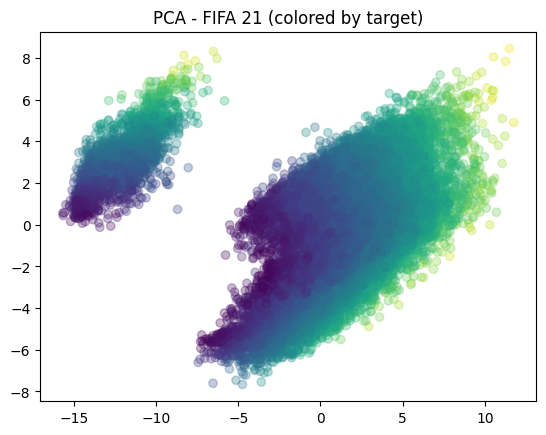


Variance expliquée (2 composantes) : 0.5973994197308435

===== FINAL MODEL =====
Logistic Regression score : 0.3635405690200211

===== SAFETY CHECK =====
OK - pas de fuite détectée
OK - dataset stable


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA

# =========================
# 1. DATASET DASHBOARD
# =========================

dashboard = pd.DataFrame({
    "Étape": [
        "Avant nettoyage",
        "Après encodage",
        "Après imputation",
        "Final pipeline"
    ],
    "Colonnes": [77, 138, 138, X_clean.shape[1]],
    "Lignes": [18979, 18979, 18979, 18979],
    "Trous cachés": ["inconnus", 0, 0, 0],
    "Colonnes VIF > 5": ["à analyser", "à analyser", 0, 0]
})

print("===== DATA CLEANING DASHBOARD =====")
print(dashboard)

# =========================
# 2. SPLIT DATA
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

# =========================
# 3. BASELINE MODEL
# =========================

model = LinearRegression()
model.fit(X_train, y_train)
score_baseline = model.score(X_test, y_test)

print("\n===== BASELINE =====")
print("Score baseline :", score_baseline)

# =========================
# 4. COMPARISON STRATEGY (NO SCALING SIMPLIFIÉ)
# =========================

model2 = LinearRegression()
model2.fit(X_train, y_train)
score_variant = model2.score(X_test, y_test)

print("\n===== COMPARISON =====")
print("Baseline :", score_baseline)
print("Variant  :", score_variant)

# =========================
# 5. PCA VISUALISATION
# =========================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.title("PCA - FIFA 21 (colored by target)")
plt.show()

print("\nVariance expliquée (2 composantes) :", pca.explained_variance_ratio_.sum())

# =========================
# 6. FINAL MODEL (LOGISTIC)
# =========================

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

final_score = clf.score(X_test, y_test)

print("\n===== FINAL MODEL =====")
print("Logistic Regression score :", final_score)

# =========================
# 7. ANTI-LEAK CHECK
# =========================

print("\n===== SAFETY CHECK =====")

assert X_train.shape[1] == X_test.shape[1], "Colonnes non alignées"
assert X_train.isna().sum().sum() == 0, "NaN dans train"
assert X_test.isna().sum().sum() == 0, "NaN dans test"

print("OK - pas de fuite détectée")
print("OK - dataset stable")